# Notebook 04: Data Mining — Sklearn Decision Tree

> **KDD Step 4**: Data Mining (sklearn implementation)
>
> Cùng dữ liệu, cùng criterion, cùng max_depth, cùng random_state.
> So sánh công bằng với from scratch (NB03).

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/thacbao/Documents/project/kpdl


## 1. Load Processed Data

In [2]:
with open("data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

print(f"Scenario A features: {len(data['scenario_A']['feature_names'])}")
print(f"Scenario B features: {len(data['scenario_B']['feature_names'])}")

Scenario A features: 63
Scenario B features: 62


## 2. Train — Scenario A (Benchmark)

> **Cùng điều kiện tuyệt đối với NB03:**
> - criterion = gini
> - max_depth = 5
> - random_state = 42
> - Cùng train/test data
> - positive_label = "yes"

In [3]:
d_A = data["scenario_A"]

print("=" * 60)
print("  SCENARIO A: BENCHMARK (CÓ DURATION) — SKLEARN")
print("=" * 60)

sk_A = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
sk_A.fit(d_A["X_train"], d_A["y_train"])
y_sk_A = sk_A.predict(d_A["X_test"])

print(f"Tree depth: {sk_A.get_depth()}")
print(f"Tree leaves: {sk_A.get_n_leaves()}")
print(f"\n{classification_report(d_A['y_test'], y_sk_A, target_names=['no', 'yes'])}")

  SCENARIO A: BENCHMARK (CÓ DURATION) — SKLEARN
Tree depth: 5
Tree leaves: 31

              precision    recall  f1-score   support

          no       0.94      0.97      0.95      7308
         yes       0.65      0.51      0.57       928

    accuracy                           0.91      8236
   macro avg       0.80      0.74      0.76      8236
weighted avg       0.91      0.91      0.91      8236



### 2.1 Visualize sklearn Tree — Scenario A

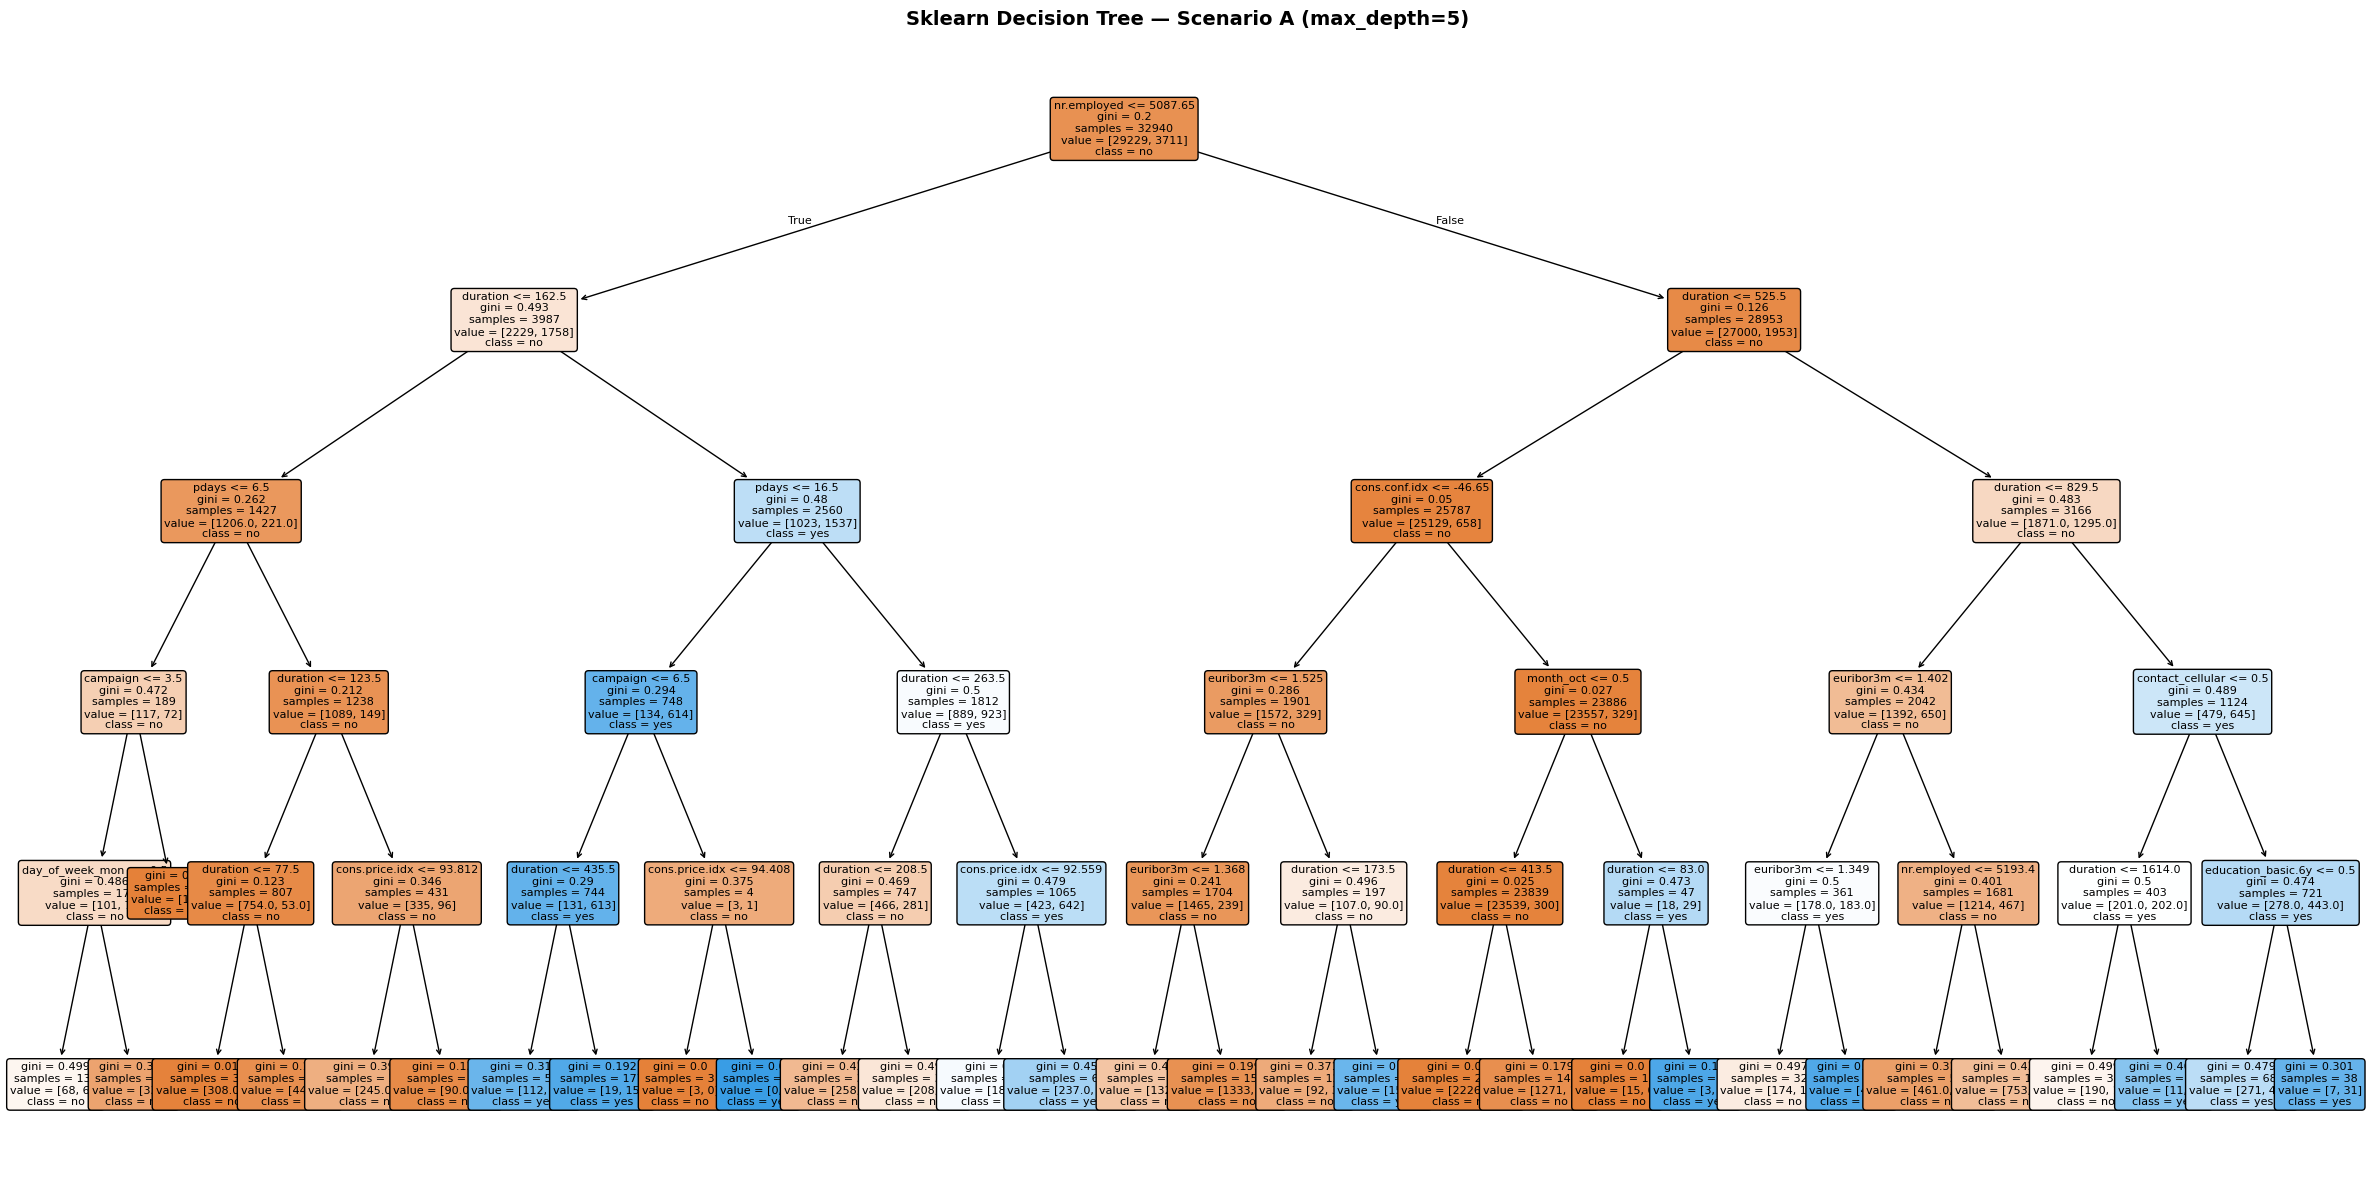

In [4]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(sk_A, feature_names=d_A["feature_names"],
         class_names=["no", "yes"], filled=True, rounded=True,
         fontsize=8, ax=ax)
ax.set_title("Sklearn Decision Tree — Scenario A (max_depth=5)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/04_sklearn_tree_A.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Feature Importance — Scenario A

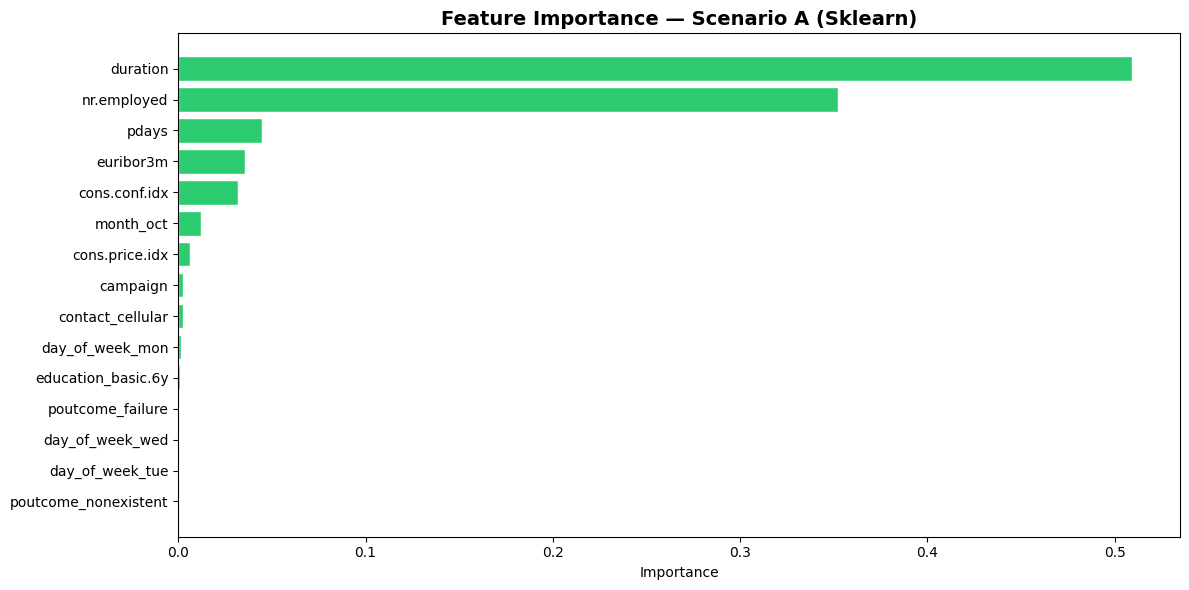

In [5]:
imp_sk_A = sk_A.feature_importances_
idx = np.argsort(imp_sk_A)[::-1][:15]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(idx)), imp_sk_A[idx][::-1], color="#2ecc71", edgecolor="white")
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([d_A["feature_names"][i] for i in idx][::-1])
ax.set_xlabel("Importance")
ax.set_title("Feature Importance — Scenario A (Sklearn)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/04_feature_importance_sk_A.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Train — Scenario B (Realistic)

In [6]:
d_B = data["scenario_B"]

print("=" * 60)
print("  SCENARIO B: REALISTIC (KHÔNG DURATION) — SKLEARN")
print("=" * 60)

sk_B = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
sk_B.fit(d_B["X_train"], d_B["y_train"])
y_sk_B = sk_B.predict(d_B["X_test"])

print(f"Tree depth: {sk_B.get_depth()}")
print(f"Tree leaves: {sk_B.get_n_leaves()}")
print(f"\n{classification_report(d_B['y_test'], y_sk_B, target_names=['no', 'yes'])}")

  SCENARIO B: REALISTIC (KHÔNG DURATION) — SKLEARN
Tree depth: 5
Tree leaves: 32

              precision    recall  f1-score   support

          no       0.91      0.98      0.95      7308
         yes       0.65      0.26      0.37       928

    accuracy                           0.90      8236
   macro avg       0.78      0.62      0.66      8236
weighted avg       0.88      0.90      0.88      8236



### 3.1 Feature Importance — Scenario B

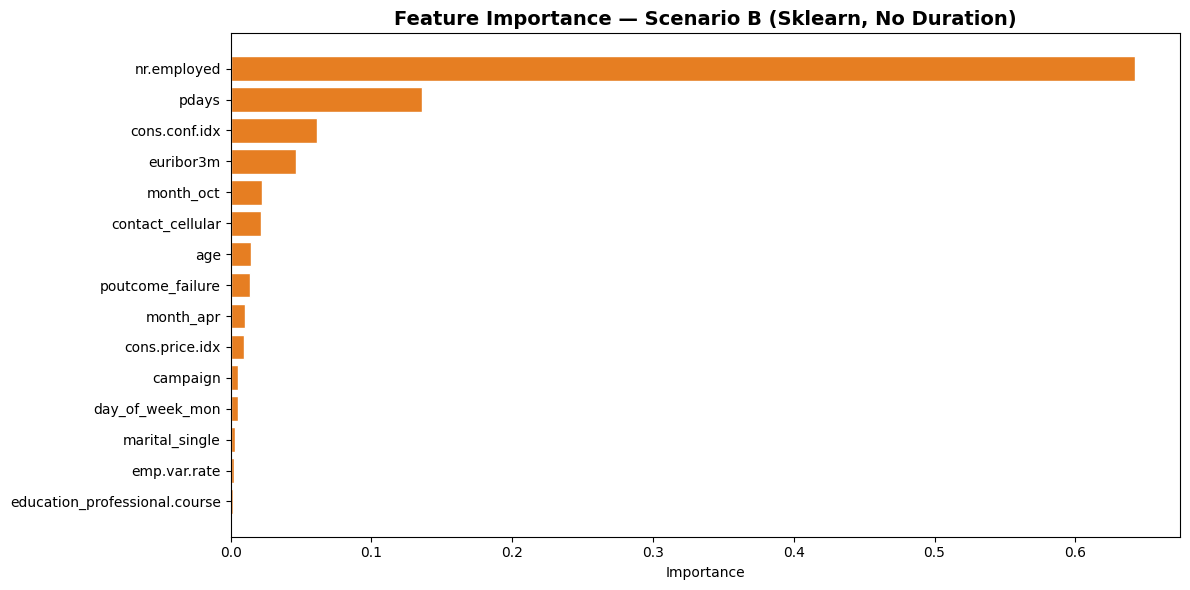

In [7]:
imp_sk_B = sk_B.feature_importances_
idx_B = np.argsort(imp_sk_B)[::-1][:15]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(idx_B)), imp_sk_B[idx_B][::-1], color="#e67e22", edgecolor="white")
ax.set_yticks(range(len(idx_B)))
ax.set_yticklabels([d_B["feature_names"][i] for i in idx_B][::-1])
ax.set_xlabel("Importance")
ax.set_title("Feature Importance — Scenario B (Sklearn, No Duration)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/04_feature_importance_sk_B.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Lưu kết quả

In [8]:
sk_report_A = classification_report(d_A["y_test"], y_sk_A, target_names=["no", "yes"], output_dict=True)
sk_report_B = classification_report(d_B["y_test"], y_sk_B, target_names=["no", "yes"], output_dict=True)

results_sklearn = {
    "scenario_A": {
        "y_pred": y_sk_A,
        "report": sk_report_A,
        "feature_importance": imp_sk_A,
        "feature_names": d_A["feature_names"],
        "tree_depth": sk_A.get_depth(),
        "tree_leaves": sk_A.get_n_leaves(),
    },
    "scenario_B": {
        "y_pred": y_sk_B,
        "report": sk_report_B,
        "feature_importance": imp_sk_B,
        "feature_names": d_B["feature_names"],
        "tree_depth": sk_B.get_depth(),
        "tree_leaves": sk_B.get_n_leaves(),
    }
}

with open("data/results_sklearn.pkl", "wb") as f:
    pickle.dump(results_sklearn, f)

print("Saved: data/results_sklearn.pkl")

Saved: data/results_sklearn.pkl
